In [ ]:
conda install -c conda-forge caiman

In [ ]:
import bokeh.plotting as bpl
import cv2
import glob
import holoviews as hv
from IPython import get_ipython
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import psutil

import caiman as cm
from caiman.source_extraction import cnmf
from caiman.source_extraction.cnmf.cnmf import load_CNMF
from caiman.utils.utils import download_demo
from caiman.utils.visualization import inspect_correlation_pnr, nb_inspect_correlation_pnr
from caiman.motion_correction import MotionCorrect
from caiman.source_extraction.cnmf import params as params
from caiman.utils.visualization import plot_contours, nb_view_patches, nb_plot_contour
from caiman.utils.visualization import view_quilt

try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
        # get_ipython().run_line_magic('matplotlib', 'qt')  #uncomment to run in qt mode
except NameError:
    pass

try:
    cv2.setNumThreads(0)
except:
    pass

bpl.output_notebook()
hv.notebook_extension('bokeh')

In [ ]:
# set up logging
logfile = None # Replace with a path if you want to log to a file
logger = logging.getLogger('caiman')
# Set to logging.INFO if you want much output, potentially much more output
logger.setLevel(logging.WARNING)
logfmt = logging.Formatter('%(relativeCreated)12d [%(filename)s:%(funcName)20s():%(lineno)s] [%(process)d] %(message)s')
if logfile is not None:
    handler = logging.FileHandler(logfile)
else:
    handler = logging.StreamHandler()
handler.setFormatter(logfmt)
logger.addHandler(handler)

# set env variables in case they weren't already set
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

In [ ]:
print(f"You have {psutil.cpu_count()} CPUs available in your current environment")
num_processors_to_use = None

In [ ]:
#%% start a cluster for parallel processing (if a cluster already exists it will be closed and a new session will be opened)
if 'cluster' in locals():  # 'locals' contains list of current local variables
    print('Closing previous cluster')
    cm.stop_server(dview=cluster)
print("Setting up new cluster")
_, cluster, n_processes = cm.cluster.setup_cluster(backend='multiprocessing', 
                                                 n_processes=num_processors_to_use, 
                                                 ignore_preexisting=False)
print(f"Successfully set up cluster with {n_processes} processes")

In [ ]:
import tifffile
import numpy as np
import os

def prepare_movie_for_motion_correction(
    raw_tif_path,
    scale_mode="uint8",         # or 'uint16'
    rescale_factor=None,        # e.g., 16 for 12-bit
    output_dir=None,            # defaults to raw_tif_path/preprocessed
    force=False,                # overwrite if exists
    return_data=False           # optionally return numpy array
):
    """
    Rescales a raw TIFF to 8- or 16-bit and saves to disk.

    Parameters:
    - raw_tif_path (str): path to the original .ome.tif file
    - scale_mode (str): 'uint8' or 'uint16'
    - rescale_factor (float or None): fixed divisor (e.g. 16), or auto-estimated
    - output_dir (str or None): folder to save preprocessed image
    - force (bool): overwrite output if it already exists
    - return_data (bool): return the scaled array along with path

    Returns:
    - out_file (str): path to scaled TIFF
    - data_scaled (ndarray): if return_data=True
    """

    print(f"📂 Loading: {raw_tif_path}")
    with tifffile.TiffFile(raw_tif_path) as tif:
        data = tif.asarray()

    # Determine scaling
    if scale_mode == "uint8":
        if rescale_factor is None:
            rescale_factor = data.max() / 255.0
        data_scaled = (data / rescale_factor).clip(0, 255).astype(np.uint8)

    elif scale_mode == "uint16":
        if rescale_factor is None:
            rescale_factor = 1
        data_scaled = (data / rescale_factor).clip(0, np.iinfo(np.uint16).max).astype(np.uint16)

    else:
        raise ValueError("scale_mode must be 'uint8' or 'uint16'")

    # Setup output path
    base_dir = os.path.dirname(raw_tif_path)
    output_dir = output_dir or os.path.join(base_dir, "preprocessed")
    os.makedirs(output_dir, exist_ok=True)

    base_name = os.path.splitext(os.path.basename(raw_tif_path))[0]
    out_file = os.path.join(output_dir, f"{base_name}_{scale_mode}.tif")

    if os.path.exists(out_file) and not force:
        print(f"⏩ Skipping: {out_file} already exists.")
    else:
        print(f"💾 Saving to: {out_file}")
        tifffile.imwrite(out_file, data_scaled, photometric='minisblack')
        os.sync()
        print(f"✅ Saved ({os.path.getsize(out_file) / 1e6:.2f} MB)")

    return (out_file, data_scaled) if return_data else out_file

In [ ]:
raw_tif_path="/Volumes/Manny2TB/murphy_lab_scope_calcium_imaging/8825_1_7331_05252025/slice2_rcamp_side1_40x_MMStack_Pos0.ome.tif"


prepped_path, data_preview = prepare_movie_for_motion_correction(
    raw_tif_path=raw_tif_path,
    scale_mode="uint8",
    rescale_factor=16,     # for 12-bit data
    return_data=True       # preview in notebook
)


In [ ]:
movie_path = '/Volumes/Manny2TB/murphy_lab_scope_calcium_imaging/8825_1_7331_05252025/preprocessed/slice2_rcamp_side1_40x_MMStack_Pos0.ome_uint8.tif'
print(f"📂 Using prepped movie: {movie_path}")

In [ ]:
movie_path = '/Volumes/Manny2TB/data_endoscope.tif' 

In [ ]:
# press q to close
movie_orig = cm.load(movie_path) 
downsampling_ratio = 0.2  # subsample 5x
movie_orig.resize(fz=downsampling_ratio).play(gain=0.9,
                                              q_max=99.5, 
                                              fr=10,
                                              plot_text=True,
                                              magnification=4,
                                              do_loop=True,
                                              backend='opencv')

In [ ]:
print(f"You have {psutil.cpu_count()} CPUs available in your current environment")
num_processors_to_use = None

In [ ]:
#%% start a cluster for parallel processing (if a cluster already exists it will be closed and a new session will be opened)
if 'cluster' in locals():  # 'locals' contains list of current local variables
    print('Closing previous cluster')
    cm.stop_server(dview=cluster)
print("Setting up new cluster")
_, cluster, n_processes = cm.cluster.setup_cluster(backend='multiprocessing', 
                                                 n_processes=num_processors_to_use, 
                                                 ignore_preexisting=False)
print(f"Successfully set up cluster with {n_processes} processes")

In [ ]:
# dataset dependent parameters
frate = 10                       # movie frame rate
decay_time = 0.4                 # length of a typical transient in seconds

# motion correction parameters
motion_correct = True    # flag for performing motion correction
pw_rigid = False         # flag for performing piecewise-rigid motion correction (otherwise just rigid)
gSig_filt = (3, 3)       # sigma for high pass spatial filter applied before motion correction, used in 1p data
max_shifts = (5, 5)      # maximum allowed rigid shift
strides = (48, 48)       # start a new patch for pw-rigid motion correction every x pixels
overlaps = (24, 24)      # overlap between patches (size of patch = strides + overlaps)
max_deviation_rigid = 3  # maximum deviation allowed for patch with respect to rigid shifts
border_nan = 'copy'      # replicate values along the boundaries

mc_dict = {
    'fnames': movie_path,
    'fr': frate,
    'decay_time': decay_time,
    'pw_rigid': pw_rigid,
    'max_shifts': max_shifts,
    'gSig_filt': gSig_filt,
    'strides': strides,
    'overlaps': overlaps,
    'max_deviation_rigid': max_deviation_rigid,
    'border_nan': border_nan
}

parameters = params.CNMFParams(params_dict=mc_dict)

In [ ]:
%%time
if motion_correct:
    # do motion correction rigid
    mot_correct = MotionCorrect(movie_path, dview=cluster, **parameters.get_group('motion'))
    mot_correct.motion_correct(save_movie=True)
    fname_mc = mot_correct.fname_tot_els if pw_rigid else mot_correct.fname_tot_rig
    if pw_rigid:
        bord_px = np.ceil(np.maximum(np.max(np.abs(mot_correct.x_shifts_els)),
                                     np.max(np.abs(mot_correct.y_shifts_els)))).astype(int)
    else:
        bord_px = np.ceil(np.max(np.abs(mot_correct.shifts_rig))).astype(int)
        # Plot shifts
        plt.plot(mot_correct.shifts_rig)  # % plot rigid shifts
        plt.legend(['x shifts', 'y shifts'])
        plt.xlabel('frames')
        plt.ylabel('pixels')
        plt.gcf().set_size_inches(6,3)

    bord_px = 0 if border_nan == 'copy' else bord_px
    fname_new = cm.save_memmap(fname_mc, base_name='memmap_', order='C',
                               border_to_0=bord_px)
else:  # if no motion correction just memory map the file
    fname_new = cm.save_memmap(movie_path, base_name='memmap_',
                               order='C', border_to_0=0, dview=dview)

In [ ]:
movie_corrected = cm.load(mot_correct.mmap_file) # load motion corrected movie
ds_ratio = 0.2
cm.concatenate([movie_orig.resize(1, 1, ds_ratio) - mot_correct.min_mov*mot_correct.nonneg_movie,
                movie_corrected.resize(1, 1, ds_ratio)], 
                axis=2).play(fr=10, 
                             gain=0.9, 
                             magnification=2) 

In [ ]:
# load memory mappable file
Yr, dims, T = cm.load_memmap(fname_new)
images = Yr.T.reshape((T,) + dims, order='F')

In [ ]:
# parameters for source extraction and deconvolution
p = 1               # order of the autoregressive system
K = None            # upper bound on number of components per patch, in general None for CNMFE
gSig = np.array([3, 3])  # expected half-width of neurons in pixels 
gSiz = 2*gSig + 1     # half-width of bounding box created around neurons during initialization
merge_thr = .7      # merging threshold, max correlation allowed
rf = 40             # half-size of the patches in pixels. e.g., if rf=40, patches are 80x80
stride_cnmf = 20    # amount of overlap between the patches in pixels 
tsub = 2            # downsampling factor in time for initialization, increase if you have memory problems
ssub = 1            # downsampling factor in space for initialization, increase if you have memory problems
gnb = 0             # number of background components (rank) if positive, set to 0 for CNMFE
low_rank_background = None  # None leaves background of each patch intact (use True if gnb>0)
nb_patch = 0        # number of background components (rank) per patch (0 for CNMFE)
min_corr = .8       # min peak value from correlation image
min_pnr = 10        # min peak to noise ration from PNR image
ssub_B = 2          # additional downsampling factor in space for background (increase to 2 if slow)
ring_size_factor = 1.4  # radius of ring is gSiz*ring_size_factor

parameters.change_params(params_dict={'method_init': 'corr_pnr',  # use this for 1 photon
                                'K': K,
                                'gSig': gSig,
                                'gSiz': gSiz,
                                'merge_thr': merge_thr,
                                'p': p,
                                'tsub': tsub,
                                'ssub': ssub,
                                'rf': rf,
                                'stride': stride_cnmf,
                                'only_init': True,    # set it to True to run CNMF-E
                                'nb': gnb,
                                'nb_patch': nb_patch,
                                'method_deconvolution': 'oasis',       # could use 'cvxpy' alternatively
                                'low_rank_background': low_rank_background,
                                'update_background_components': True,  # sometimes setting to False improve the results
                                'min_corr': min_corr,
                                'min_pnr': min_pnr,
                                'normalize_init': False,               # just leave as is
                                'center_psf': True,                    # True for 1p
                                'ssub_B': ssub_B,
                                'ring_size_factor': ring_size_factor,
                                'del_duplicates': True,                # whether to remove duplicates from initialization
                                'border_pix': bord_px});                # number of pixels to not consider in the borders)

In [ ]:
cnmfe_model = cnmf.CNMF(n_processes=n_processes, 
                        dview=cluster, 
                        params=parameters)

In [ ]:
print(gSig)
gsig_tmp = (6,6)
correlation_image, peak_to_noise_ratio = cm.summary_images.correlation_pnr(images[::max(T//1000, 1)], # subsample if needed
                                                                           gSig=gsig_tmp[0], # used for filter
                                                                           swap_dim=False) # change swap dim if output looks weird, it is a problem with tiffile

In [ ]:
nb_inspect_correlation_pnr(correlation_image, peak_to_noise_ratio, cmap='inferno') # jet, fire are also good cmaps


In [ ]:
gsig_new = gSig # unchanged
min_corr_new  = 0.85 
min_pnr_new = 12     

cnmfe_model.params.change_params(params_dict={'gSig': gsig_new,
                                              'min_corr': min_corr_new, 
                                              'min_pnr': min_pnr_new});

In [ ]:
# calculate stride and overlap from parameters
cnmfe_patch_width = cnmfe_model.params.patch['rf']*2 + 1
cnmfe_patch_overlap = cnmfe_model.params.patch['stride'] + 1
cnmfe_patch_stride = cnmfe_patch_width - cnmfe_patch_overlap
print(f'Patch width: {cnmfe_patch_width} , Stride: {cnmfe_patch_stride}, Overlap: {cnmfe_patch_overlap}');

# plot the patches
patch_ax = view_quilt(correlation_image, 
                      cnmfe_patch_stride, 
                      cnmfe_patch_overlap, 
                      vmin=np.percentile(np.ravel(correlation_image), 50), 
                      vmax=np.percentile(np.ravel(correlation_image), 99.5),
                      color='yellow',
                      figsize=(4,4));
patch_ax.set_title(f'CNMFE Patch Width {cnmfe_patch_width}, Overlap {cnmfe_patch_overlap}');


In [ ]:
%%time
cnmfe_model.fit(images);

In [ ]:
min_SNR = 3            # SNR threshold
rval_thr = 0.85    # spatial correlation threshold

quality_params = {'min_SNR': min_SNR,
                  'rval_thr': rval_thr,
                  'use_cnn': False}
cnmfe_model.params.change_params(params_dict=quality_params)

cnmfe_model.estimates.evaluate_components(images, cnmfe_model.params, dview=cluster)

print('*****')
print(f"Total number of components: {len(cnmfe_model.estimates.C)}")
print(f"Number accepted: {len(cnmfe_model.estimates.idx_components)}")
print(f"Number rejected: {len(cnmfe_model.estimates.idx_components_bad)}")

In [ ]:
#%% plot contour plots of accepted and rejected components
cnmfe_model.estimates.plot_contours_nb(img=correlation_image, 
                                       idx=cnmfe_model.estimates.idx_components);

In [ ]:
cnmfe_model.estimates.nb_view_components(img=correlation_image, 
                                        idx=cnmfe_model.estimates.idx_components,
                                        cmap='viridis', #gray
                                        thr=.9); #increase to see full footprint

In [ ]:
# rejected components
cnmfe_model.estimates.nb_view_components(img=correlation_image, 
                                        idx=cnmfe_model.estimates.idx_components_bad,
                                        cmap='viridis', #gray
                                        denoised_color='red',
                                        thr=0.9); #increase to see full footprint

In [ ]:
if cnmfe_model.estimates.F_dff is None:
    print('Calculating estimates.F_dff')
    cnmfe_model.estimates.detrend_df_f(quantileMin=8, 
                                      frames_window=250,
                                      flag_auto=False,
                                      use_residuals=False);  # use denoised data
else:
    print("estimates.F_dff already defined")

In [ ]:
# in case you are working from loaded data, recover the raw movie
Yr, dims, num_frames = cm.load_memmap(cnmfe_model.mmap_file)
images = np.reshape(Yr.T, [num_frames] + list(dims), order='F')

In [ ]:
neural_activity = cnmfe_model.estimates.A[:, cnmfe_model.estimates.idx_components] @\
                  cnmfe_model.estimates.C[cnmfe_model.estimates.idx_components, :]  # AC
neural_movie = cm.movie(neural_activity).reshape(dims + (-1,), order='F').transpose([2, 0, 1])
background_model = cnmfe_model.estimates.compute_background(Yr);  # build in function -- explore source code for details
bg_movie = cm.movie(background_model).reshape(dims + (-1,), order='F').transpose([2, 0, 1])

In [ ]:
downsampling_ratio = 0.4 
neural_movie.resize(fz=downsampling_ratio).play(gain=1.1,
                                            q_max=99.5, 
                                            fr=20,
                                            plot_text=True,
                                            magnification=2,
                                            do_loop=False,
                                            backend='opencv')

In [ ]:
# without background
cnmfe_model.estimates.play_movie(images, 
                                 q_max=99.9, 
                                 magnification=2,
                                 include_bck=False,
                                 gain_res=5,
                                 use_color=True);

In [ ]:
cm.stop_server(dview=cluster)

In [ ]:
# Shut down logger (otherwise will not be able to delete it)
logging.shutdown()

In [ ]:
delete_logs = True
logging_dir = cm.paths.get_tempdir() 
if delete_logs:
    log_files = glob.glob(logging_dir + '\\demo_pipeline' + '*' + '.log')
    for log_file in log_files:
        print(f"Deleting {log_file}")
        os.remove(log_file)
else:
    print(f"If you want to inspect your logs they are in {logging_dir}")

# now process our data

In [ ]:
# set up logging
logfile = None # Replace with a path if you want to log to a file
logger = logging.getLogger('caiman')
# Set to logging.INFO if you want much output, potentially much more output
logger.setLevel(logging.WARNING)
logfmt = logging.Formatter('%(relativeCreated)12d [%(filename)s:%(funcName)20s():%(lineno)s] [%(process)d] %(message)s')
if logfile is not None:
    handler = logging.FileHandler(logfile)
else:
    handler = logging.StreamHandler()
handler.setFormatter(logfmt)
logger.addHandler(handler)

# set env variables in case they weren't already set
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

In [ ]:
movie_path = '/Volumes/Manny2TB/murphy_lab_scope_calcium_imaging/8825_1_7331_05252025/preprocessed/slice2_rcamp_side1_40x_MMStack_Pos0.ome_uint8.tif'
print(f"📂 Using prepped movie: {movie_path}")

In [ ]:
# press q to close
movie_orig = cm.load(movie_path) 
downsampling_ratio = 0.2  # subsample 5x
movie_orig.resize(fz=downsampling_ratio).play(gain=0.9,
                                              q_max=99.5, 
                                              fr=33.33,
                                              plot_text=True,
                                              magnification=4,
                                              do_loop=True,
                                              backend='opencv')

In [ ]:
print(f"You have {psutil.cpu_count()} CPUs available in your current environment")
num_processors_to_use = None

In [ ]:
#%% start a cluster for parallel processing (if a cluster already exists it will be closed and a new session will be opened)
if 'cluster' in locals():  # 'locals' contains list of current local variables
    print('Closing previous cluster')
    cm.stop_server(dview=cluster)
print("Setting up new cluster")
_, cluster, n_processes = cm.cluster.setup_cluster(backend='multiprocessing', 
                                                 n_processes=num_processors_to_use, 
                                                 ignore_preexisting=False)
print(f"Successfully set up cluster with {n_processes} processes")

In [ ]:
	
# dataset dependent parameters
frate = 33.33                      # movie frame rate
decay_time = 0.4                 # length of a typical transient in seconds

# motion correction parameters
motion_correct = True    # flag for performing motion correction
pw_rigid = False         # flag for performing piecewise-rigid motion correction (otherwise just rigid)
gSig_filt = (3, 3)       # sigma for high pass spatial filter applied before motion correction, used in 1p data
max_shifts = (5, 5)      # maximum allowed rigid shift
strides = (48, 48)       # start a new patch for pw-rigid motion correction every x pixels
overlaps = (24, 24)      # overlap between patches (size of patch = strides + overlaps)
max_deviation_rigid = 3  # maximum deviation allowed for patch with respect to rigid shifts
border_nan = 'copy'      # replicate values along the boundaries

mc_dict = {
    'fnames': movie_path,
    'fr': frate,
    'decay_time': decay_time,
    'pw_rigid': pw_rigid,
    'max_shifts': max_shifts,
    'gSig_filt': gSig_filt,
    'strides': strides,
    'overlaps': overlaps,
    'max_deviation_rigid': max_deviation_rigid,
    'border_nan': border_nan
}

parameters = params.CNMFParams(params_dict=mc_dict)

In [ ]:
%%time
if motion_correct:
    # do motion correction rigid
    mot_correct = MotionCorrect(movie_path, dview=cluster, **parameters.get_group('motion'))
    mot_correct.motion_correct(save_movie=True)
    fname_mc = mot_correct.fname_tot_els if pw_rigid else mot_correct.fname_tot_rig
    if pw_rigid:
        bord_px = np.ceil(np.maximum(np.max(np.abs(mot_correct.x_shifts_els)),
                                     np.max(np.abs(mot_correct.y_shifts_els)))).astype(int)
    else:
        bord_px = np.ceil(np.max(np.abs(mot_correct.shifts_rig))).astype(int)
        # Plot shifts
        plt.plot(mot_correct.shifts_rig)  # % plot rigid shifts
        plt.legend(['x shifts', 'y shifts'])
        plt.xlabel('frames')
        plt.ylabel('pixels')
        plt.gcf().set_size_inches(6,3)

    bord_px = 0 if border_nan == 'copy' else bord_px
    fname_new = cm.save_memmap(fname_mc, base_name='memmap_', order='C',
                               border_to_0=bord_px)
else:  # if no motion correction just memory map the file
    fname_new = cm.save_memmap(movie_path, base_name='memmap_',
                               order='C', border_to_0=0, dview=dview)

In [ ]:
movie_corrected = cm.load(mot_correct.mmap_file) # load motion corrected movie
ds_ratio = 0.2
cm.concatenate([movie_orig.resize(1, 1, ds_ratio) - mot_correct.min_mov*mot_correct.nonneg_movie,
                movie_corrected.resize(1, 1, ds_ratio)], 
                axis=2).play(fr=33.33, 
                             gain=0.9, 
                             magnification=2) 

In [ ]:
# load memory mappable file
Yr, dims, T = cm.load_memmap(fname_new)
images = Yr.T.reshape((T,) + dims, order='F')

In [ ]:
# parameters for source extraction and deconvolution
p = 1               # order of the autoregressive system
K = None            # upper bound on number of components per patch, in general None for CNMFE
gSig = np.array([3, 3])  # expected half-width of neurons in pixels 
gSiz = 2*gSig + 1     # half-width of bounding box created around neurons during initialization
merge_thr = .7      # merging threshold, max correlation allowed
rf = 40             # half-size of the patches in pixels. e.g., if rf=40, patches are 80x80
stride_cnmf = 20    # amount of overlap between the patches in pixels 
tsub = 2            # downsampling factor in time for initialization, increase if you have memory problems
ssub = 1            # downsampling factor in space for initialization, increase if you have memory problems
gnb = 0             # number of background components (rank) if positive, set to 0 for CNMFE
low_rank_background = None  # None leaves background of each patch intact (use True if gnb>0)
nb_patch = 0        # number of background components (rank) per patch (0 for CNMFE)
min_corr = .8       # min peak value from correlation image
min_pnr = 10        # min peak to noise ration from PNR image
ssub_B = 2          # additional downsampling factor in space for background (increase to 2 if slow)
ring_size_factor = 1.4  # radius of ring is gSiz*ring_size_factor

parameters.change_params(params_dict={'method_init': 'corr_pnr',  # use this for 1 photon
                                'K': K,
                                'gSig': gSig,
                                'gSiz': gSiz,
                                'merge_thr': merge_thr,
                                'p': p,
                                'tsub': tsub,
                                'ssub': ssub,
                                'rf': rf,
                                'stride': stride_cnmf,
                                'only_init': True,    # set it to True to run CNMF-E
                                'nb': gnb,
                                'nb_patch': nb_patch,
                                'method_deconvolution': 'oasis',       # could use 'cvxpy' alternatively
                                'low_rank_background': low_rank_background,
                                'update_background_components': True,  # sometimes setting to False improve the results
                                'min_corr': min_corr,
                                'min_pnr': min_pnr,
                                'normalize_init': False,               # just leave as is
                                'center_psf': True,                    # True for 1p
                                'ssub_B': ssub_B,
                                'ring_size_factor': ring_size_factor,
                                'del_duplicates': True,                # whether to remove duplicates from initialization
                                'border_pix': bord_px});                # number of pixels to not consider in the borders

In [ ]:
cnmfe_model = cnmf.CNMF(n_processes=n_processes, 
                        dview=cluster, 
                        params=parameters)

In [ ]:
print(gSig)
gsig_tmp = (3,3)
correlation_image, peak_to_noise_ratio = cm.summary_images.correlation_pnr(images[::max(T//1000, 1)], # subsample if needed
                                                                           gSig=gsig_tmp[0], # used for filter
                                                                           swap_dim=False) # change swap dim if output looks weird, it is a problem with tiffile


In [ ]:
nb_inspect_correlation_pnr(correlation_image, peak_to_noise_ratio, cmap='inferno') # jet, fire are also good cmaps


In [ ]:
# calculate stride and overlap from parameters
cnmfe_patch_width = cnmfe_model.params.patch['rf']*2 + 1
cnmfe_patch_overlap = cnmfe_model.params.patch['stride'] + 1
cnmfe_patch_stride = cnmfe_patch_width - cnmfe_patch_overlap
print(f'Patch width: {cnmfe_patch_width} , Stride: {cnmfe_patch_stride}, Overlap: {cnmfe_patch_overlap}');

# plot the patches
patch_ax = view_quilt(correlation_image, 
                      cnmfe_patch_stride, 
                      cnmfe_patch_overlap, 
                      vmin=np.percentile(np.ravel(correlation_image), 50), 
                      vmax=np.percentile(np.ravel(correlation_image), 99.5),
                      color='yellow',
                      figsize=(4,4));
patch_ax.set_title(f'CNMFE Patch Width {cnmfe_patch_width}, Overlap {cnmfe_patch_overlap}');

In [ ]:
cnmfe_model.params.change_params(params_dict={'gSig': gsig_new,
                                              'min_corr': min_corr_new, 
                                              'min_pnr': min_pnr_new});

In [ ]:
# Update CNMF-E patch parameters (patch size and stride)
cnmfe_model.params.change_params(params_dict={
    'rf': 50,        # Patch radius → width = 65
    'stride': 70     # Distance between patch centers
})

# Recalculate patch dimensions from updated parameters
cnmfe_patch_width = cnmfe_model.params.patch['rf'] * 2 + 1
cnmfe_patch_overlap = cnmfe_patch_width - cnmfe_model.params.patch['stride']
cnmfe_patch_stride = cnmfe_model.params.patch['stride']

print(f"Patch width: {cnmfe_patch_width}, Stride: {cnmfe_patch_stride}, Overlap: {cnmfe_patch_overlap}")

# Visualize patch tiling using updated parameters
patch_ax = view_quilt(correlation_image, 
                      cnmfe_patch_stride, 
                      cnmfe_patch_overlap, 
                      vmin=np.percentile(np.ravel(correlation_image), 50), 
                      vmax=np.percentile(np.ravel(correlation_image), 99.5),
                      color='yellow',
                      figsize=(4, 4))

patch_ax.set_title(f'CNMFE Patch Width {cnmfe_patch_width}, Overlap {cnmfe_patch_overlap}');

In [ ]:
%%time
cnmfe_model.fit(images);

In [ ]:
min_SNR = 3            # SNR threshold
rval_thr = 0.85    # spatial correlation threshold

quality_params = {'min_SNR': min_SNR,
                  'rval_thr': rval_thr,
                  'use_cnn': False}
cnmfe_model.params.change_params(params_dict=quality_params)

cnmfe_model.estimates.evaluate_components(images, cnmfe_model.params, dview=cluster)

print('*****')
print(f"Total number of components: {len(cnmfe_model.estimates.C)}")
print(f"Number accepted: {len(cnmfe_model.estimates.idx_components)}")
print(f"Number rejected: {len(cnmfe_model.estimates.idx_components_bad)}")

In [ ]:
#%% plot contour plots of accepted and rejected components
cnmfe_model.estimates.plot_contours_nb(img=correlation_image, 
                                       idx=cnmfe_model.estimates.idx_components);

In [ ]:
cnmfe_model.estimates.nb_view_components(img=correlation_image, 
                                        idx=cnmfe_model.estimates.idx_components,
                                        cmap='viridis', #gray
                                        thr=.9); #increase to see full footprint

In [ ]:
# rejected components
cnmfe_model.estimates.nb_view_components(img=correlation_image, 
                                        idx=cnmfe_model.estimates.idx_components_bad,
                                        cmap='viridis', #gray
                                        denoised_color='red',
                                        thr=0.9); #increase to see full footprint

demo - motion correction 

In [ ]:
import cv2
from IPython import get_ipython
import matplotlib.pyplot as plt
import numpy as np
import os.path
import logging

try:
    cv2.setNumThreads(0)
except:
    pass

try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass

logfile = None # Replace with a path if you want to log to a file
logger = logging.getLogger('caiman')
# Set to logging.INFO if you want much output, potentially much more output
logger.setLevel(logging.WARNING)
logfmt = logging.Formatter('%(relativeCreated)12d [%(filename)s:%(funcName)20s():%(lineno)s] [%(process)d] %(message)s')
if logfile is not None:
    handler = logging.FileHandler(logfile)
else:
    handler = logging.StreamHandler()
handler.setFormatter(logfmt)
logger.addHandler(handler)

import caiman as cm
from caiman.motion_correction import MotionCorrect, tile_and_correct, motion_correction_piecewise
from caiman.utils.utils import download_demo

In [1]:
from caiman.utils.utils import download_demo

# Download the TIFF file and return the path
path_to_file = download_demo(name='Sue_2x_3000_40_-46.tif')
print(f"File downloaded to: {path_to_file}")

File downloaded to: /Users/ecrespo/caiman_data/example_movies/Sue_2x_3000_40_-46.tif


In [2]:
from caiman.paths import caiman_datadir
import os

print(caiman_datadir())

/Users/ecrespo/caiman_data


In [3]:
os.makedirs(os.path.join(caiman_datadir(), 'example_movies'), exist_ok=True)

In [ ]:
from caiman.utils.utils import download_demo

path_to_file = download_demo(name='Sue_2x_3000_40_-46.tif')
print(path_to_file)

In [4]:
import cv2
from IPython import get_ipython
import matplotlib.pyplot as plt
import numpy as np
import os.path
import logging

try:
    cv2.setNumThreads(0)
except:
    pass

try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass

logfile = None # Replace with a path if you want to log to a file
logger = logging.getLogger('caiman')
# Set to logging.INFO if you want much output, potentially much more output
logger.setLevel(logging.WARNING)
logfmt = logging.Formatter('%(relativeCreated)12d [%(filename)s:%(funcName)20s():%(lineno)s] [%(process)d] %(message)s')
if logfile is not None:
    handler = logging.FileHandler(logfile)
else:
    handler = logging.StreamHandler()
handler.setFormatter(logfmt)
logger.addHandler(handler)

import caiman as cm
from caiman.motion_correction import MotionCorrect, tile_and_correct, motion_correction_piecewise
from caiman.utils.utils import download_demo

In [5]:
fnames = 'Sue_2x_3000_40_-46.tif'
fnames = [download_demo(fnames)]     # the file will be downloaded if it doesn't already exist
m_orig = cm.load_movie_chain(fnames)
downsample_ratio = .2  # motion can be perceived better when downsampling in time
m_orig.resize(1, 1, downsample_ratio).play(q_max=99.5, fr=30, magnification=2)   # play movie (press q to exit)

100%|██████████| 1/1 [00:00<00:00, 12.82it/s]


In [6]:
max_shifts = (6, 6)  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
strides =  (48, 48)  # create a new patch every x pixels for pw-rigid correction
overlaps = (24, 24)  # overlap between patches (size of patch strides+overlaps)
max_deviation_rigid = 3   # maximum deviation allowed for patch with respect to rigid shifts
pw_rigid = False  # flag for performing rigid or piecewise rigid motion correction
shifts_opencv = True  # flag for correcting motion using bicubic interpolation (otherwise FFT interpolation is used)
border_nan = 'copy'

In [7]:
#%% start the cluster (if a cluster already exists terminate it)
if 'dview' in locals():
    cm.stop_server(dview=dview)
c, dview, n_processes = cm.cluster.setup_cluster(
    backend='multiprocessing', n_processes=None, single_thread=False)

In [8]:
# create a motion correction object
mc = MotionCorrect(fnames, dview=dview, max_shifts=max_shifts,
                  strides=strides, overlaps=overlaps,
                  max_deviation_rigid=max_deviation_rigid, 
                  shifts_opencv=shifts_opencv, nonneg_movie=True,
                  border_nan=border_nan)

In [9]:
%%capture
# correct for rigid motion correction and save the file (in memory mapped form)
mc.motion_correct(save_movie=True)

100%|██████████| 1/1 [00:00<00:00,  8.91it/s]


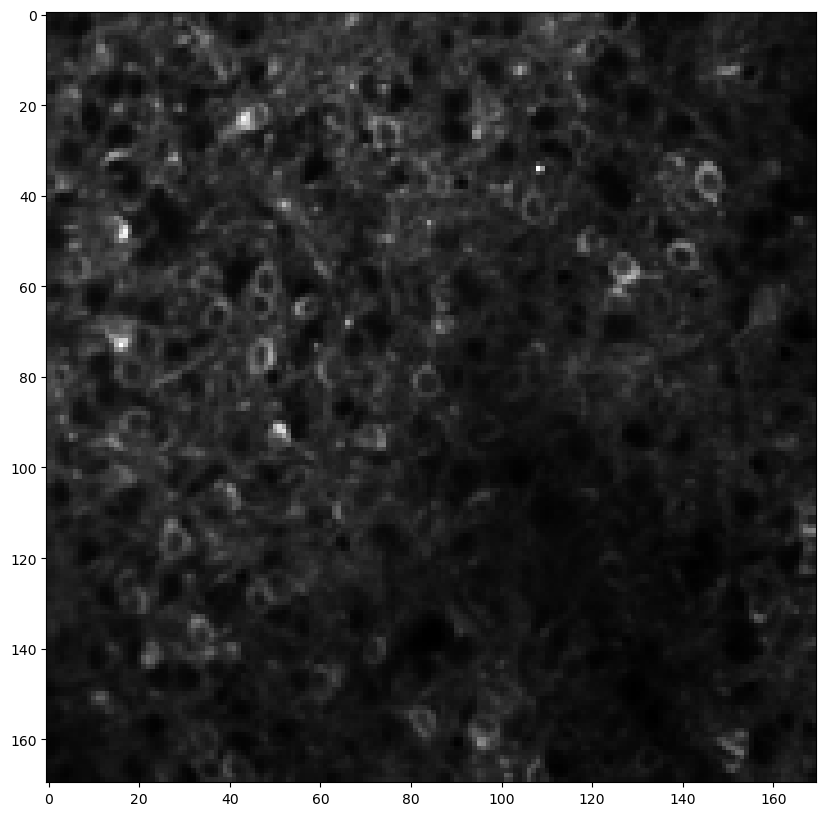

In [10]:
	
# load motion corrected movie
m_rig = cm.load(mc.mmap_file)
bord_px_rig = np.ceil(np.max(mc.shifts_rig)).astype(int)
#%% visualize templates
plt.figure(figsize = (20,10))
plt.imshow(mc.total_template_rig, cmap = 'gray');

In [11]:
#%% inspect movie
m_rig.resize(1, 1, downsample_ratio).play(
    q_max=99.5, fr=30, magnification=2, bord_px = 0*bord_px_rig) # press q to exit

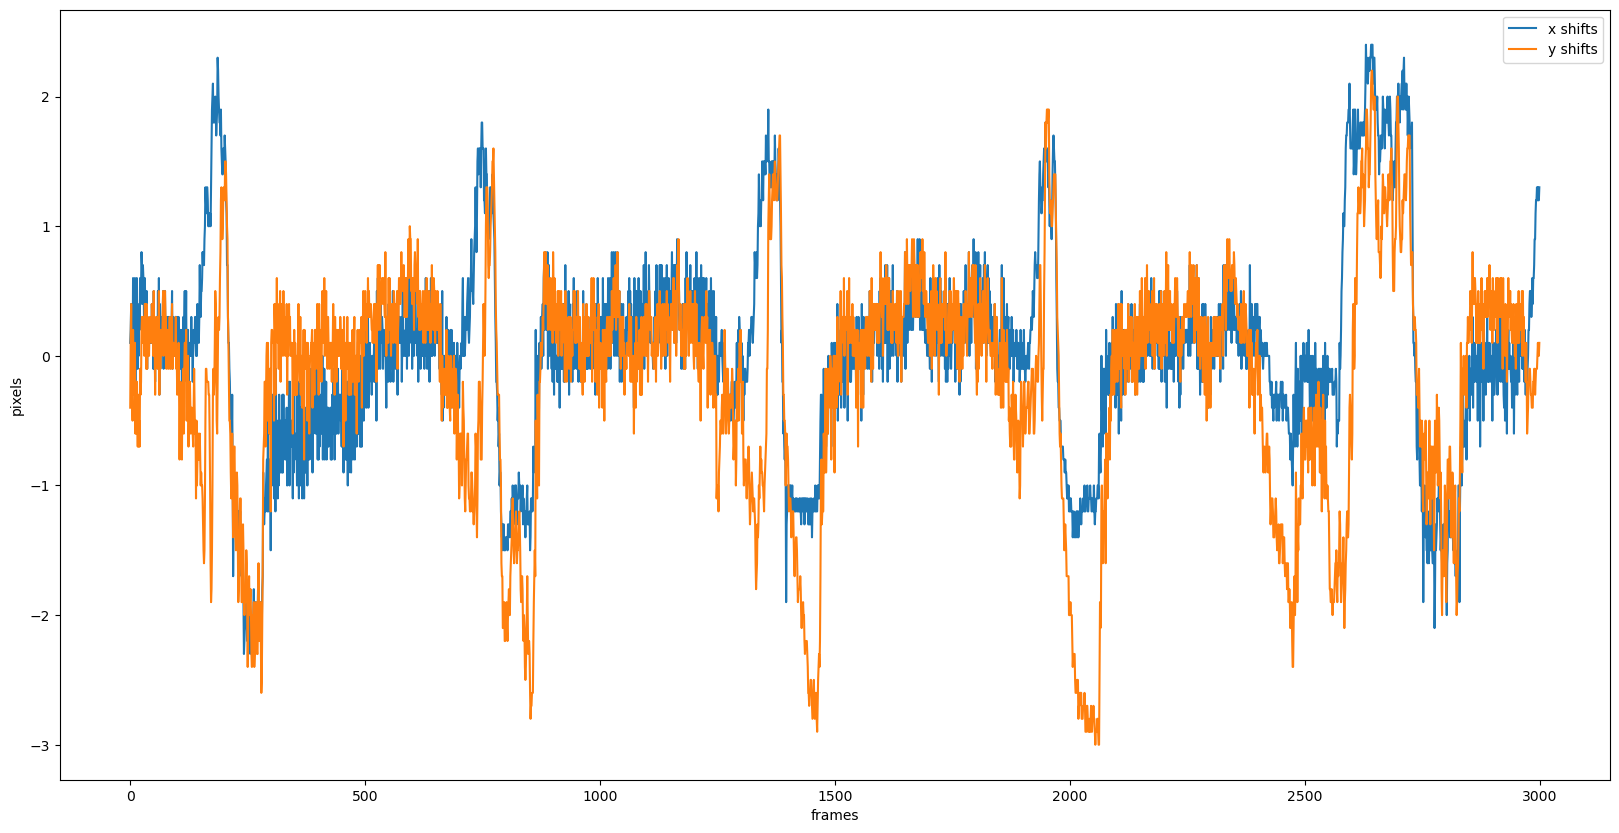

In [12]:
#%% plot rigid shifts
plt.close()
plt.figure(figsize = (20,10))
plt.plot(mc.shifts_rig)
plt.legend(['x shifts','y shifts'])
plt.xlabel('frames')
plt.ylabel('pixels');

In [13]:
%%capture
#%% motion correct piecewise rigid
mc.pw_rigid = True  # turn the flag to True for pw-rigid motion correction
mc.template = mc.mmap_file  # use the template obtained before to save in computation (optional)

mc.motion_correct(save_movie=True, template=mc.total_template_rig)
m_els = cm.load(mc.fname_tot_els)
m_els.resize(1, 1, downsample_ratio).play(
    q_max=99.5, fr=30, magnification=2,bord_px = bord_px_rig)

In [14]:
cm.concatenate([m_orig.resize(1, 1, downsample_ratio) - mc.min_mov*mc.nonneg_movie,
                m_rig.resize(1, 1, downsample_ratio), m_els.resize(
            1, 1, downsample_ratio)], axis=2).play(fr=60, q_max=99.5, magnification=2, bord_px=bord_px_rig)

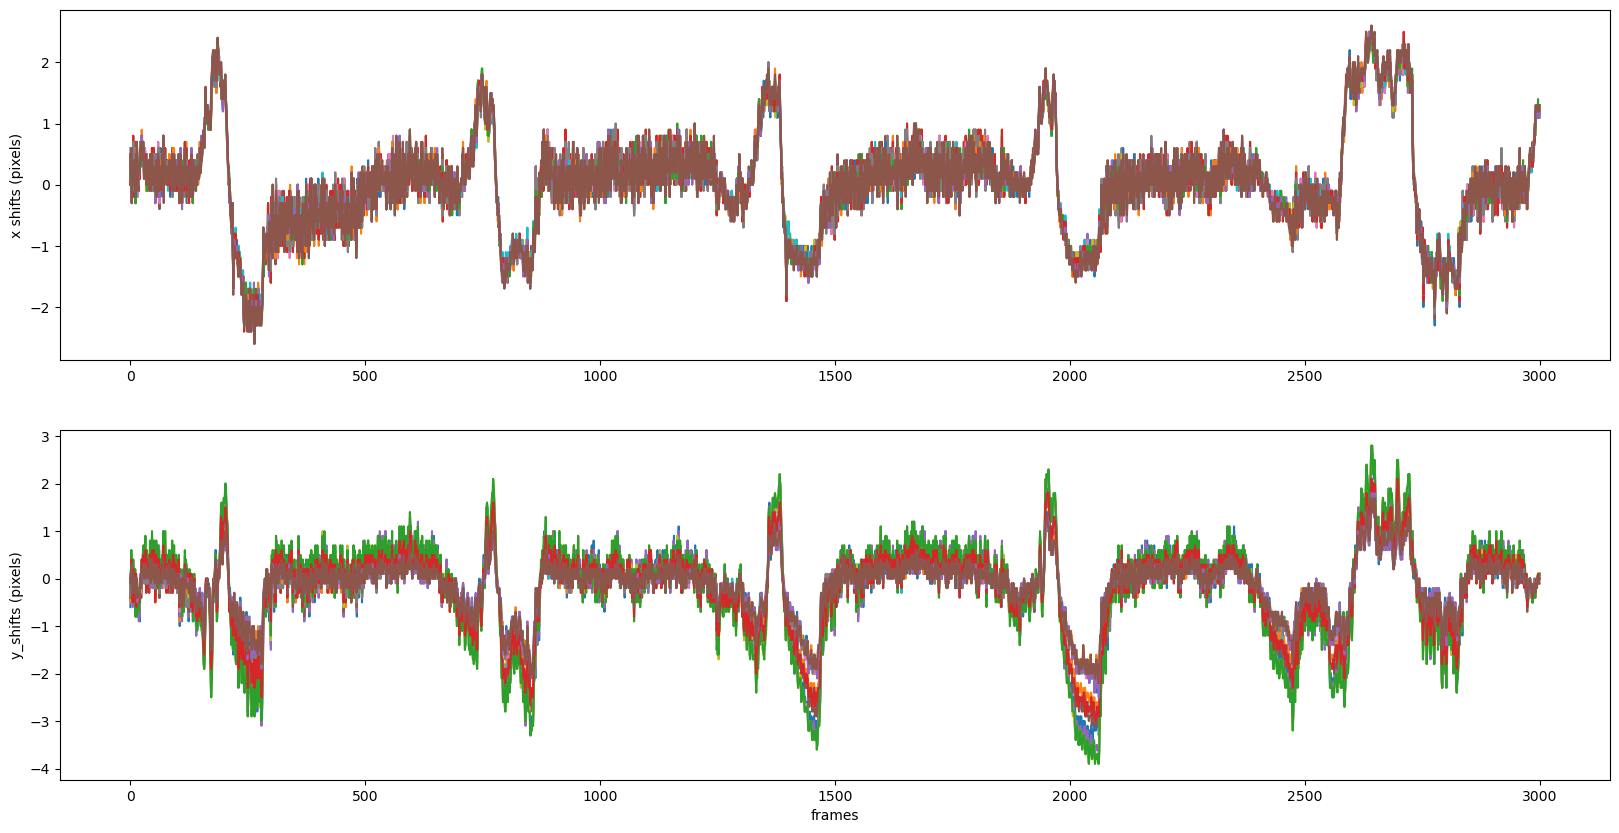

In [15]:
#%% visualize elastic shifts
plt.close()
plt.figure(figsize = (20,10))
plt.subplot(2, 1, 1)
plt.plot(mc.x_shifts_els)
plt.ylabel('x shifts (pixels)')
plt.subplot(2, 1, 2)
plt.plot(mc.y_shifts_els)
plt.ylabel('y_shifts (pixels)')
plt.xlabel('frames')
#%% compute borders to exclude
bord_px_els = np.ceil(np.maximum(np.max(np.abs(mc.x_shifts_els)),
                                 np.max(np.abs(mc.y_shifts_els)))).astype(int)

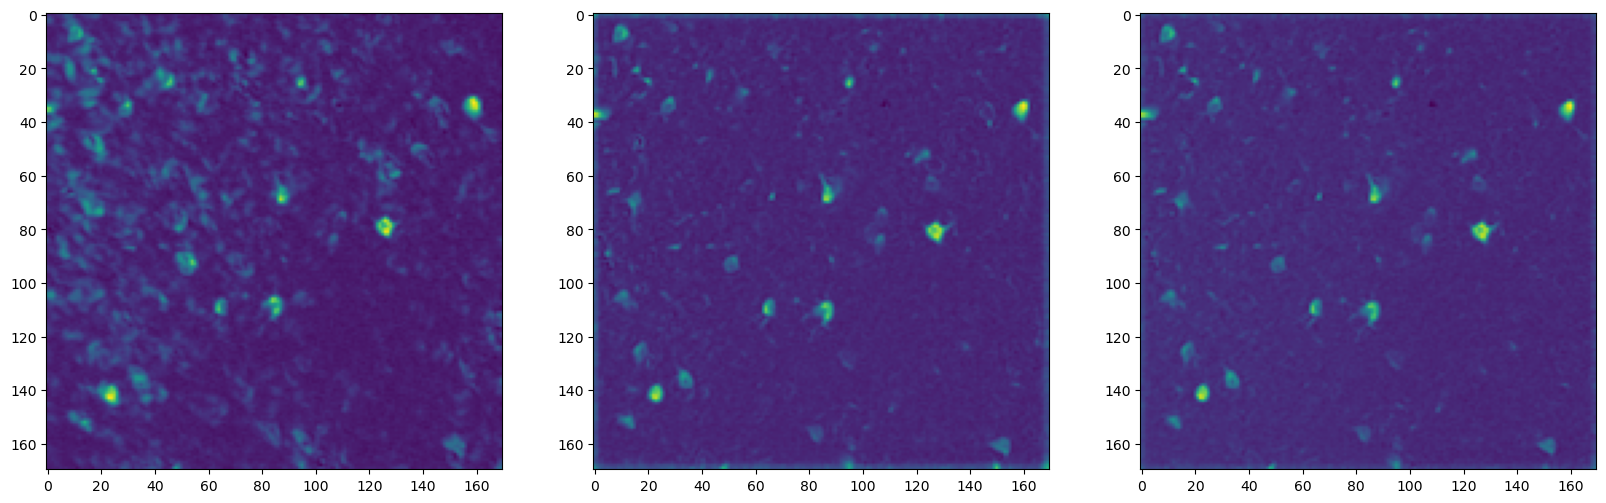

In [19]:
plt.figure(figsize = (20,10))
plt.subplot(1,3,1); plt.imshow(m_orig.local_correlations(eight_neighbours=True, swap_dim=False))
plt.subplot(1,3,2); plt.imshow(m_rig.local_correlations(eight_neighbours=True, swap_dim=False))
plt.subplot(1,3,3); plt.imshow(m_els.local_correlations(eight_neighbours=True, swap_dim=False))

In [20]:
%%capture
#% compute metrics for the results (TAKES TIME!!)
final_size = np.subtract(mc.total_template_els.shape, 2 * bord_px_els) # remove pixels in the boundaries
winsize = 100
swap_dim = False
resize_fact_flow = .2    # downsample for computing ROF

tmpl_orig, correlations_orig, flows_orig, norms_orig, crispness_orig = cm.motion_correction.compute_metrics_motion_correction(
    fnames[0], final_size[0], final_size[1], swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow)

tmpl_rig, correlations_rig, flows_rig, norms_rig, crispness_rig = cm.motion_correction.compute_metrics_motion_correction(
    mc.fname_tot_rig[0], final_size[0], final_size[1],
    swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow)

tmpl_els, correlations_els, flows_els, norms_els, crispness_els = cm.motion_correction.compute_metrics_motion_correction(
    mc.fname_tot_els[0], final_size[0], final_size[1],
    swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow)

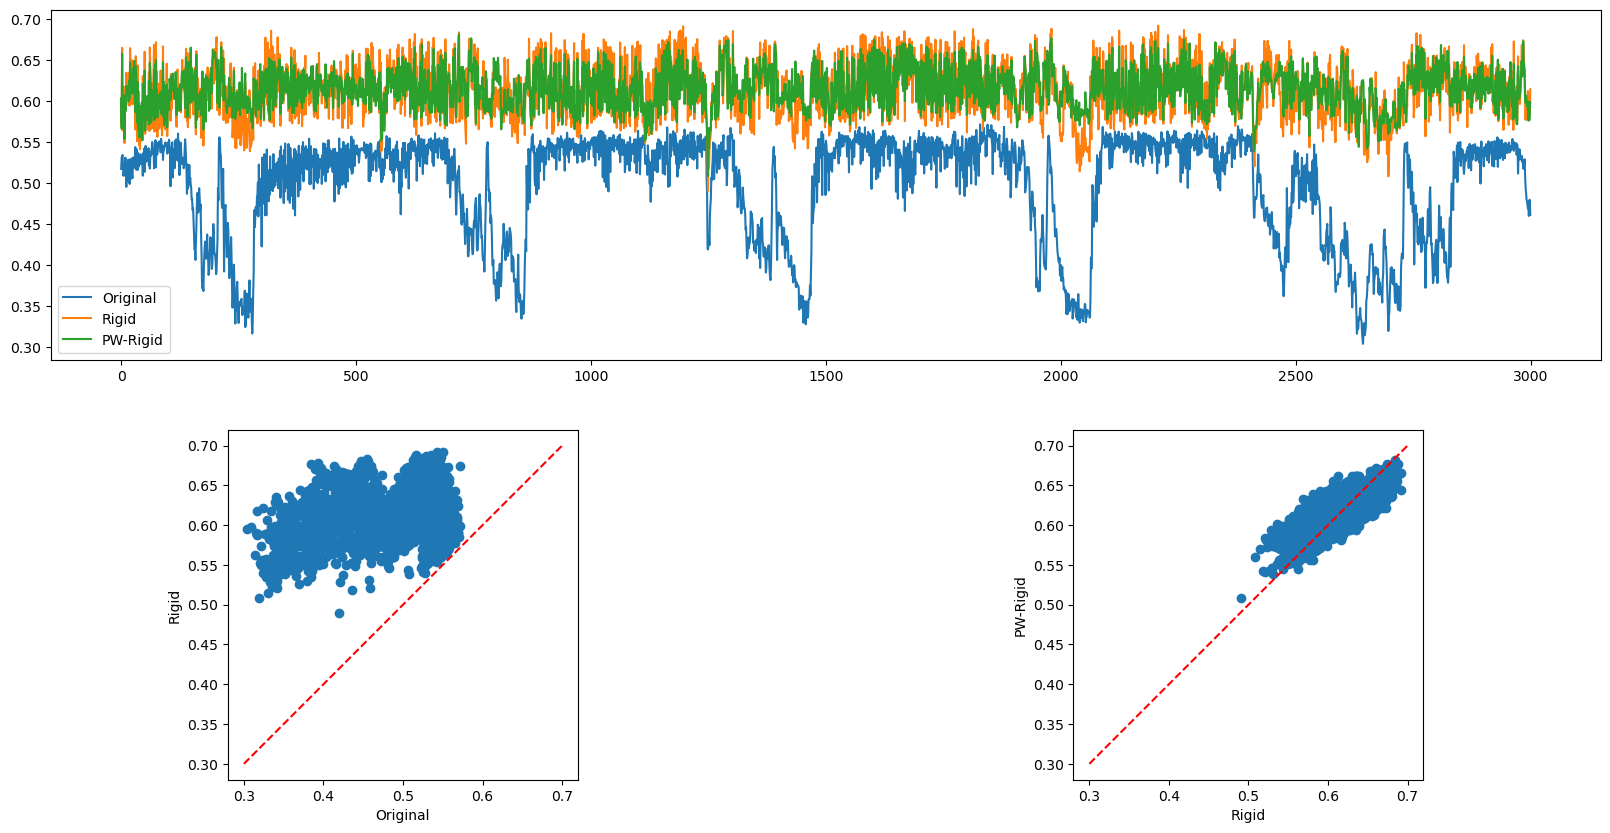

In [21]:
plt.figure(figsize = (20,10))
plt.subplot(211); plt.plot(correlations_orig); plt.plot(correlations_rig); plt.plot(correlations_els)
plt.legend(['Original','Rigid','PW-Rigid'])
plt.subplot(223); plt.scatter(correlations_orig, correlations_rig); plt.xlabel('Original'); 
plt.ylabel('Rigid'); plt.plot([0.3,0.7],[0.3,0.7],'r--')
axes = plt.gca(); axes.set_xlim([0.3,0.7]); axes.set_ylim([0.3,0.7]); plt.axis('square');
plt.subplot(224); plt.scatter(correlations_rig, correlations_els); plt.xlabel('Rigid'); 
plt.ylabel('PW-Rigid'); plt.plot([0.3,0.7],[0.3,0.7],'r--')
axes = plt.gca(); axes.set_xlim([0.3,0.7]); axes.set_ylim([0.3,0.7]); plt.axis('square');

In [22]:
# print crispness values
print('Crispness original: ' + str(int(crispness_orig)))
print('Crispness rigid: ' + str(int(crispness_rig)))
print('Crispness elastic: ' + str(int(crispness_els)))

Crispness original: 1937
Crispness rigid: 2758
Crispness elastic: 2848


ERROR:root:File request:[/Users/ecrespo/caiman_data/example_movies/Sue_2x_3000_40_-46.mmap] not found!


KeysView(NpzFile '/Users/ecrespo/caiman_data/temp/Sue_2x_3000_40_-46_els__d1_170_d2_170_d3_1_order_F_frames_3000_metrics.npz' with keys: flows, norms, correlations, smoothness, tmpl...)
/Users/ecrespo/caiman_data/temp/Sue_2x_3000_40_-46_els__d1_170_d2_170_d3_1_order_F_frames_3000_metrics.npz
15.31141+/-7.7736864 ; 2848.1125 ; 5.024257060099677
Loading data with base /Users/ecrespo/caiman_data/temp/Sue_2x_3000_40_-46_els__d1_170_d2_170_d3_1_order_F_frames_3000
KeysView(NpzFile '/Users/ecrespo/caiman_data/temp/Sue_2x_3000_40_-46_rig__d1_170_d2_170_d3_1_order_F_frames_3000_metrics.npz' with keys: flows, norms, correlations, smoothness, tmpl...)
/Users/ecrespo/caiman_data/temp/Sue_2x_3000_40_-46_rig__d1_170_d2_170_d3_1_order_F_frames_3000_metrics.npz
23.156504+/-14.882817 ; 2758.9792 ; 5.104358212421173
Loading data with base /Users/ecrespo/caiman_data/temp/Sue_2x_3000_40_-46_rig__d1_170_d2_170_d3_1_order_F_frames_3000
KeysView(NpzFile '/Users/ecrespo/caiman_data/example_movies/Sue_2x_3000

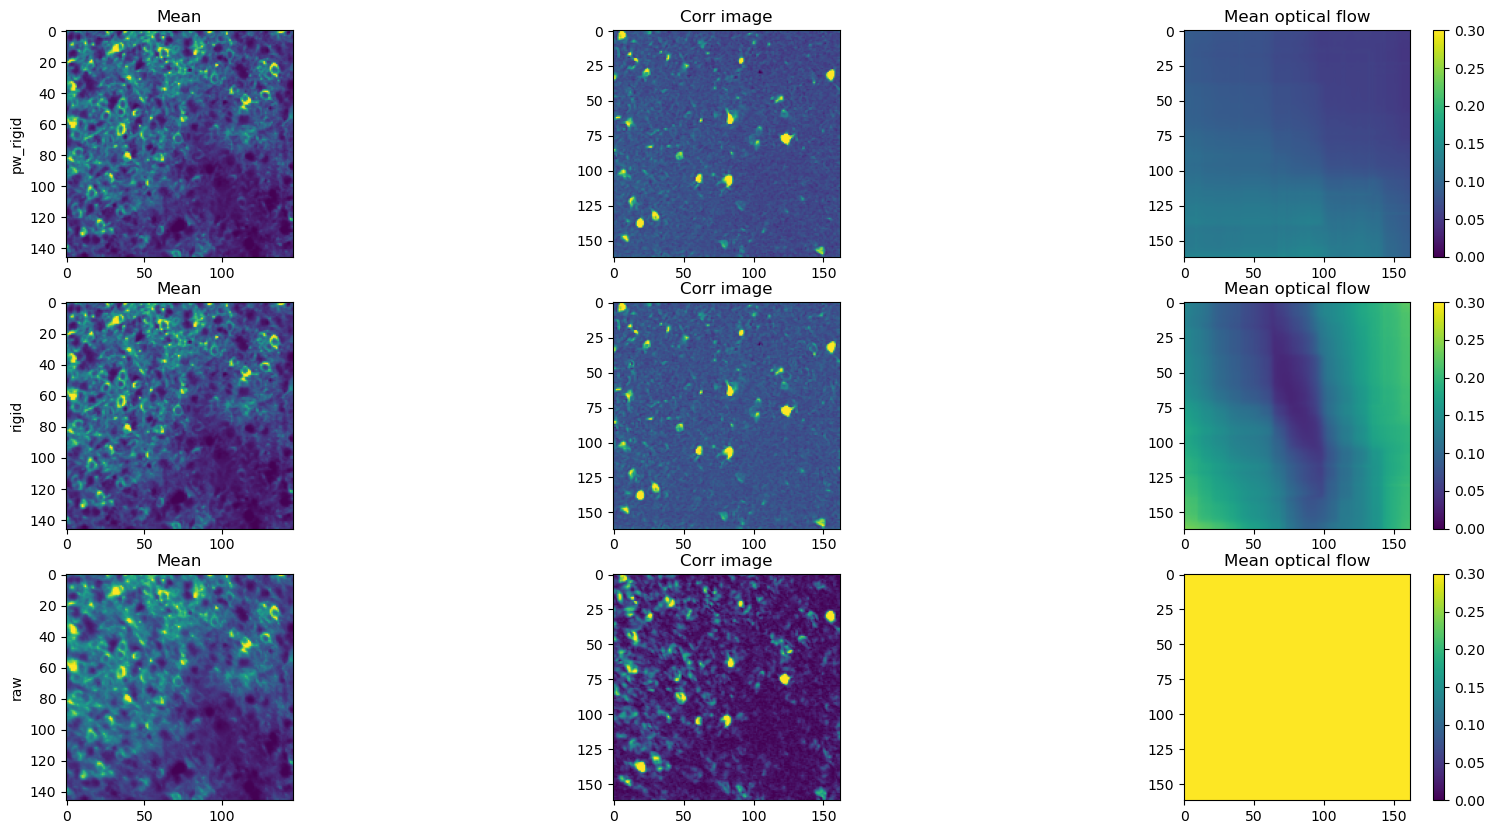

In [23]:
#%% plot the results of Residual Optical Flow
fls = [cm.paths.fname_derived_presuffix(mc.fname_tot_els[0], 'metrics', swapsuffix='npz'),
       cm.paths.fname_derived_presuffix(mc.fname_tot_rig[0], 'metrics', swapsuffix='npz'),
       cm.paths.fname_derived_presuffix(mc.fname[0],         'metrics', swapsuffix='npz'),
      ]

plt.figure(figsize = (20,10))
for cnt, fl, metr in zip(range(len(fls)), fls, ['pw_rigid','rigid','raw']):
    with np.load(fl) as ld:
        print(ld.keys())
        print(fl)
        print(str(np.mean(ld['norms'])) + '+/-' + str(np.std(ld['norms'])) +
              ' ; ' + str(ld['smoothness']) + ' ; ' + str(ld['smoothness_corr']))
        
        plt.subplot(len(fls), 3, 1 + 3 * cnt)
        plt.ylabel(metr)
        print(f"Loading data with base {fl[:-12]}")
        try:
            mean_img = np.mean(
            cm.load(fl[:-12] + '.mmap'), 0)[12:-12, 12:-12]
        except:
            try:
                mean_img = np.mean(
                    cm.load(fl[:-12] + '.tif'), 0)[12:-12, 12:-12]
            except:
                mean_img = np.mean(
                    cm.load(fl[:-12] + 'hdf5'), 0)[12:-12, 12:-12]
                    
        lq, hq = np.nanpercentile(mean_img, [.5, 99.5])
        plt.imshow(mean_img, vmin=lq, vmax=hq)
        plt.title('Mean')
        plt.subplot(len(fls), 3, 3 * cnt + 2)
        plt.imshow(ld['img_corr'], vmin=0, vmax=.35)
        plt.title('Corr image')
        plt.subplot(len(fls), 3, 3 * cnt + 3)
        flows = ld['flows']
        plt.imshow(np.mean(
        np.sqrt(flows[:, :, :, 0]**2 + flows[:, :, :, 1]**2), 0), vmin=0, vmax=0.3)
        plt.colorbar()
        plt.title('Mean optical flow');  